# 08 — Is any of this good? The comparison, with the loss attributed

Seven notebooks have measured what the CAM *does*. This one asks whether it is worth building,
which requires something to compare against — and, more importantly, requires being careful
about **which costs belong to the architecture and which were always going to be paid**.

That care is the whole content of this notebook. A raw number ("the CAM is 3.9 dB worse")
would be true and misleading. The useful number is the decomposition.

By the end you should be able to answer:

1. What is the conventional receiver actually doing, and how is it modelled here?
2. Why is a *1-bit* baseline the fair comparison rather than the full-precision one?
3. Where does the CAM's cost actually land, and how big is it?
4. What does the CAM buy in exchange, in hardware terms?

Modules: [`sim/gps/baselines.py`](../sim/gps/baselines.py),
[`sim/gps/comparison_study.py`](../sim/gps/comparison_study.py).
Published result: [`figures/gps_comparison.md`](../figures/gps_comparison.md).

In [1]:
import sys, pathlib, math
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps import channel, codebook
from sim.gps.baselines import acquire_fft, dwells_required_fft, fft_complex_macs
from sim.gps.comparison_study import run as cmp_run, ONE_BIT_POWER_FACTOR
from sim.gps.experiments import GpsConfig, independent_cells

# sim/plots.py forces the Agg backend at import; restore inline rendering.
%matplotlib inline

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
FS, T = 2.046e6, 1e-3
NS = int(round(FS * T))

---
## 1. The competitor: FFT parallel-code-phase search

The standard GNSS acquisition engine does not test code phases one at a time. For each
(PRN, Doppler) pair it wipes off the carrier and then gets **all 2046 code phases at once**
from a forward FFT, a conjugate multiply, and an inverse FFT — circular correlation via the
convolution theorem.

This is a genuinely good algorithm, and it is what the CAM has to beat or at least approach.

In [2]:
sig = channel.generate(prn=7, cn0_dbhz=48, fd=1000.0, fs=FS, n_samples=NS,
                       code_phase_chips=317.0, rng=np.random.default_rng(0))
grid = codebook.doppler_grid(10e3, T)
r = acquire_fft(sig.samples, prn=7, fd_grid=grid, fs=FS)

expected = int(round((-317.0 * 2) % NS))
print(f"planted : PRN 7, code phase 317.0 chips, fd = +1000 Hz")
print(f"found   : code phase sample {r.code_phase_samples} (expect {expected}), fd = {r.fd:+.0f} Hz")
print(f"peak/2nd ratio: {r.metric:.2f}")
print(f"\nwrong PRN check: {acquire_fft(sig.samples, 3, grid, FS).metric:.2f} (should be near 1)")

planted : PRN 7, code phase 317.0 chips, fd = +1000 Hz
found   : code phase sample 1412 (expect 1412), fd = +1000 Hz
peak/2nd ratio: 5.23

wrong PRN check: 1.03 (should be near 1)


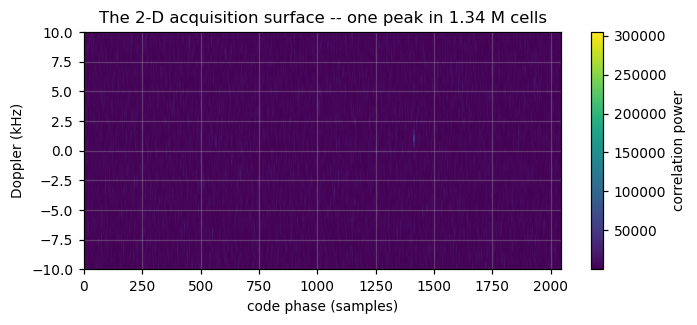

In [3]:
fig, ax = plt.subplots(figsize=(7, 2.8))
im = ax.imshow(r.grid, aspect="auto", origin="lower",
               extent=[0, NS, grid[0]/1e3, grid[-1]/1e3], cmap="viridis")
ax.set(xlabel="code phase (samples)", ylabel="Doppler (kHz)",
       title="The 2-D acquisition surface -- one peak in 1.34 M cells")
plt.colorbar(im, ax=ax, label="correlation power"); plt.show()

That surface is the thing being searched. The CAM computes the same surface — one row per
(PRN, Doppler), one code phase per clock — but reads it out through a 1-bit comparator instead
of a magnitude.

### How the baseline's dwell count is computed

Non-coherently accumulating $M$ coherent correlations gives a $\chi^2_{2M}$ statistic under
$H_0$ and a non-central $\chi^2$ with $\lambda = M \cdot 2 (C/N_0) T$ under $H_1$.
[`dwells_required_fft`](../sim/gps/baselines.py) inverts that against the *same* per-cell
false-alarm budget notebook 07 used, so the two systems are sized by one methodology.

---
## 2. The fair baseline: B1$'$

Here is the crux of the whole comparison.

Notebook 02 measured that a 1-bit front end costs **1.96 dB**, and that this is true of *any*
hard-limited receiver. Real GNSS receivers use 1–2 bit front ends. So if we compare the CAM
against a full-precision FFT, we are charging the CAM for a loss the deployed alternative also
pays.

Three reference points, therefore:

| | what it is | precision |
|---|---|---|
| **B1** | FFT parallel-code-phase search | full complex |
| **B1$'$** | the same search from 1-bit samples | 1 bit/rail |
| **CAM** | segmented approximate-match array | 1 bit/rail, **boolean readout** |

- **B1 → B1$'$** is the limiting loss. *Not chargeable to the CAM.*
- **B1$'$ → CAM** is what the boolean readout and the hard per-segment decisions cost. **This
  is the architecture's actual bill.**

In [4]:
print(f"1-bit power factor 2/pi = {ONE_BIT_POWER_FACTOR:.4f} = {10*np.log10(ONE_BIT_POWER_FACTOR):+.2f} dB")
cells = independent_cells(GpsConfig(n_segments=1, n_prn=32))
print(f"\n{'C/N0':>6} {'B1 (ms)':>9} {'effective C/N0':>15} {'B1p (ms)':>10}")
for cn0 in [38, 42]:
    m1, _ = dwells_required_fft(cn0, T, cells)
    eff = 10*np.log10(10**(cn0/10) * ONE_BIT_POWER_FACTOR)
    m2, _ = dwells_required_fft(eff, T, cells)
    print(f"{cn0:>6} {m1:>9} {eff:>14.2f} {m2:>10}")

1-bit power factor 2/pi = 0.6366 = -1.96 dB

  C/N0   B1 (ms)  effective C/N0   B1p (ms)
    38         6          36.04         11
    42         2          40.04          4


> **Be clear about what this is.** B1$'$ is *modelled*, not simulated: we degrade C/N0 by
> 1.96 dB and re-run the same sizing. That is legitimate because notebook 02 measured the
> 1.96 dB directly on this signal chain (−1.965 dB against a predicted −1.961 dB), so we are
> applying a verified constant rather than an assumed one. But it is an analytic step, and it
> assumes the limiting loss is the *only* effect of quantizing the baseline — which is exactly
> true for the correlator output SNR and is why the shortcut is safe here.

---
## 3. The result

In [5]:
res = cmp_run(trials=3000, seed=42)
rows = res["rows"]

print(f"{'C/N0':>7} {'S':>3} {'B1':>6} {'B1p':>6} {'CAM':>6} {'CAM vs B1p':>12} {'dict':>10}")
for k, (cn0, S, b1, b1p, cam) in enumerate(rows):
    i = [1, 2, 3, 6, 11].index(int(S))
    print(f"{cn0:>5.0f}dB {int(S):>3} {int(b1):>4}ms {int(b1p):>4}ms {int(cam):>4}ms "
          f"{10*np.log10(cam/b1p):>+11.1f} dB {res['dict_bits'][i]/1e6:>7.2f} Mb")

   C/N0   S     B1    B1p    CAM   CAM vs B1p       dict
   38dB   1    6ms   11ms   17ms        +1.9 dB    5.37 Mb
   38dB   2    6ms   11ms   23ms        +3.2 dB    2.75 Mb
   38dB   3    6ms   11ms   27ms        +3.9 dB    1.96 Mb
   38dB   6    6ms   11ms   42ms        +5.8 dB    1.18 Mb
   38dB  11    6ms   11ms   65ms        +7.7 dB    0.65 Mb
   42dB   1    2ms    4ms    6ms        +1.8 dB    5.37 Mb
   42dB   2    2ms    4ms    7ms        +2.4 dB    2.75 Mb
   42dB   3    2ms    4ms    7ms        +2.4 dB    1.96 Mb
   42dB   6    2ms    4ms   10ms        +4.0 dB    1.18 Mb
   42dB  11    2ms    4ms   13ms        +5.1 dB    0.65 Mb


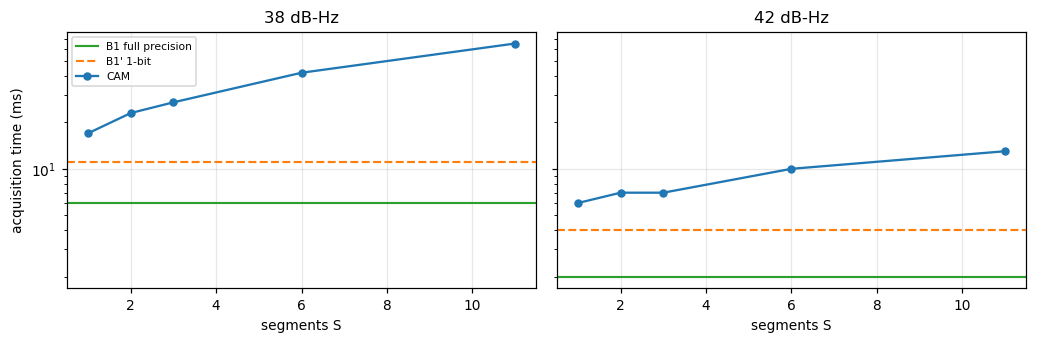

The gap to the dashed line is the architecture's bill. The gap between
the two horizontal lines was always going to be paid by any 1-bit receiver.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
for ax, cn0 in zip(axes, [38, 42]):
    sub = rows[rows[:, 0] == cn0]
    ax.axhline(sub[0, 2], color="C2", ls="-", lw=1.4, label="B1 full precision")
    ax.axhline(sub[0, 3], color="C1", ls="--", lw=1.4, label="B1' 1-bit")
    ax.plot(sub[:, 1], sub[:, 4], "o-", color="C0", ms=4.5, label="CAM")
    ax.set(xlabel="segments S", title=f"{cn0:.0f} dB-Hz", yscale="log")
axes[0].set_ylabel("acquisition time (ms)")
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("The gap to the dashed line is the architecture's bill. The gap between")
print("the two horizontal lines was always going to be paid by any 1-bit receiver.")

**At $S=1$ the boolean-readout tax is +1.9 dB** (17 ms vs 11 ms at 38 dB-Hz). That is the
headline number of the GPS study, and it is a good deal better than the equivalent figure in
the BLE work — for the reason notebook 03 set up: GNSS acquisition wants a *detection plus a
bin index*, not an estimate, so discarding the magnitude costs comparatively little.

The tax then grows with segmentation, from +1.9 dB to +7.7 dB at $S=11$, which is simply
notebook 05's hard-decision cost showing up in the currency of the comparison.

In [7]:
print("A note on the dB conversion. The penalty is quoted as 10*log10(time ratio),")
print("which assumes required time scales as 1/SNR. Check that against the model:\n")
cn0s = np.arange(35, 46)
ms = np.array([dwells_required_fft(c, T, cells)[0] for c in cn0s])
ok = ms > 0
slope = np.polyfit(cn0s[ok] / 10, np.log10(ms[ok]), 1)[0]
print(f"   fit over 35-45 dB-Hz:  M ~ SNR^{slope:.2f}   (exactly -1 would justify 10*log10)")
print(f"   so a ratio R is really {-10/slope:.1f}*log10(R) dB, not 10*log10(R)")
print(f"   headline +1.9 dB would be {-10/slope*np.log10(17/11):+.2f} dB under the fitted exponent")
print("\nA 0.15 dB effect -- the convention is sound, but worth knowing it is a convention.")

A note on the dB conversion. The penalty is quoted as 10*log10(time ratio),
which assumes required time scales as 1/SNR. Check that against the model:

   fit over 35-45 dB-Hz:  M ~ SNR^-1.07   (exactly -1 would justify 10*log10)
   so a ratio R is really 9.3*log10(R) dB, not 10*log10(R)
   headline +1.9 dB would be +1.76 dB under the fitted exponent

A 0.15 dB effect -- the convention is sound, but worth knowing it is a convention.


---
## 4. What is bought in exchange

Time is only half the ledger. The other half is what the two engines cost to build, and here
they are not remotely comparable objects — which is the point.

In [8]:
print(f"FFT engine, one full 2-D search : {res['fft_macs']/1e6:.1f} M complex MAC per dwell")
print(f"                                  (plus the memory to hold a 41 x 2046 complex grid)")
print()
print(f"{'S':>3} {'dictionary':>12} {'match-line cells':>18} {'time@38':>9}")
for i, S in enumerate([1, 2, 3, 6, 11]):
    cam = rows[(rows[:, 0] == 38) & (rows[:, 1] == S)][0, 4]
    print(f"{S:>3} {res['dict_bits'][i]/1e6:>9.2f} Mb {res['ml_cells'][i]/1e6:>15.2f} M "
          f"{int(cam):>7}ms")
print("\nThe CAM has no multiplier, no accumulator, no complex arithmetic at all --")
print("it is SRAM plus comparators. That is the trade: MACs for bits.")

FFT engine, one full 2-D search : 32.2 M complex MAC per dwell
                                  (plus the memory to hold a 41 x 2046 complex grid)

  S   dictionary   match-line cells   time@38
  1      5.37 Mb            5.37 M      17ms
  2      2.75 Mb            2.75 M      23ms
  3      1.96 Mb            1.96 M      27ms
  6      1.18 Mb            1.18 M      42ms
 11      0.65 Mb            0.65 M      65ms

The CAM has no multiplier, no accumulator, no complex arithmetic at all --
it is SRAM plus comparators. That is the trade: MACs for bits.


The comparison is therefore not "which is faster" but **which cost you would rather pay**:

- The FFT engine spends **32.2 M complex MACs per dwell** and needs real arithmetic, a
  multiplier array, and working memory for a complex grid.
- The CAM spends **0.65–5.4 Mbit of storage** and comparators, and takes 1.5–6× longer.

For a continuously-powered, power-limited receiver doing cold starts rarely, that can be a
good trade. For a receiver that must acquire fast, it is not. **The study's job is to price the
trade, not to declare a winner** — which is why the deliverable is a curve.

---
## 5. Where this honestly lands

Pulling the whole series together into the claim that is actually supported:

**What works.** The placement principle (sweep what is free, store what is not) is sound and
measurable: $\theta_0$ costs zero rows and is exact (nb 02), while Doppler genuinely cannot be
swept (nb 02 §7). The detection physics matches theory to sub-percent once the reference is
unbiased (nb 04). The sizing model is validated, not assumed (nb 07 §1). And the boolean
readout costs **+1.9 dB**, which for an application that wants a bin index rather than an
estimate is a real result.

**What it costs.** A sense amplifier resolving ~1 part in 128, i.e. 6–7 effective bits on a
4092-cell match line (nb 06). Not exotic, but not a bare comparator either — the architecture
needs a *calibrated* comparator, and match-line non-idealities must hold to about 1%.

**What we have not shown.** Nothing here is a circuit. Every "area" number is a bit count, not
a layout; every "one cycle" is an assumption about what a match line can do. The +1.9 dB is
measured against a *modelled* 1-bit baseline (§2). And the whole study lives at one operating
point — 32 PRNs, ±10 kHz, AWGN, no multipath, no data-bit transitions, which at 20 ms would
cut across the longer dwell counts in the table.

> That last item is the most important caveat and worth stating plainly: **at 38 dB-Hz the
> $S{=}11$ configuration needs 65 ms of accumulation, and GPS navigation data flips sign every
> 20 ms.** The long-dwell end of the curve is not physical without data wipe-off or a
> differential detector. The short-dwell end ($S = 1$–3, 17–27 ms) is close to that boundary
> too. This does not invalidate the trade curve, but it does mean the *usable* region is the
> left-hand end — which is, conveniently, the same region notebook 07's marginal-return
> analysis pointed at.

## The series, end to end

| nb | question | headline |
|---|---|---|
| 01 | what arrives at the antenna | one dwell is not enough at 38 dB-Hz, for anyone |
| 02 | what does 1-bit cost | 1.96 dB, measured to 0.004 dB of theory |
| 03 | what does the CAM return | booleans only; the $\theta_0$ sweep is load-bearing, not an optimization |
| 04 | is the model right | yes, to 0.98 once the $H_0$ reference is unbiased |
| 05 | why segment | 8.2× smaller dictionary, paid for with a hard decision |
| 06 | how precise must the sense amp be | 1 part in 128 → ~7 bits |
| 07 | how long does it take | 17–65 ms; efficient region is $S = 1$–3 |
| 08 | is it any good | +1.9 dB over an equivalent 1-bit correlator, for MACs → bits |

### Try it yourself
- Re-run §3 with `f_max=5e3` (a warm start). Does the CAM's relative position improve or worsen? Why?
- The 20 ms data-bit limit above: what $S$ and C/N0 combinations in the table are actually reachable?
- Implement a crude data wipe-off (accumulate $|{\cdot}|$ over 20 ms blocks) for B1 and see how much of the gap it closes.